# Support Ticket → Department Classifier

**Goal:** given the text of a customer support ticket, predict which department should handle it.

**Dataset:** [Multilingual Customer Support Tickets](https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets) — Kaggle, `tobiasbueck/multilingual-customer-support-tickets`.
28,587 tickets in English and German, 16 columns. The label is `queue`, which holds the department name.

**The 10 departments:** Technical Support, Product Support, Customer Service, IT Support,
Billing and Payments, Returns and Exchanges, Service Outages and Maintenance, Sales and Pre-Sales,
Human Resources, General Inquiry. *(Counts and balance are examined in Step 4.)*

> **This is topic classification, not sentiment analysis.** We are sorting tickets into
> departments, not measuring whether the customer is happy or angry. Worth stating up front
> because it changes which metrics matter.

---

### Pipeline map

| Steps | Phase | What happens |
|---|---|---|
| 1–4 | **Understand** | Setup, load, inspect, check which columns could leak the answer, study the label |
| 5–10 | **Clean** | Build text field, handle missing values, kill duplicates, decide on language |
| 11–14 | **Prepare** | Rare classes, split, vectorize, handle imbalance |
| 15–16 | **Baseline** | Train 4 models, compare them fairly |
| 17–19 | **Improve** | Tune, analyse errors, fix confidence scores |
| 20 | **Finalize** | Test once, save, document limitations |

### One rule that runs through all of it

Anything learned from data — vocabulary, weights, scaling, resampling — is fitted on the
**training set only**. The moment test data influences training, the final score stops
meaning anything.

---

# Phase 1 — Understand the data
*Steps 1 to 4*

> **Phase 1 is descriptive.** It looks at all 28,587 tickets — including the ones that will later
> become the test set. That is acceptable only because nothing measured here is fed into the model:
> no vocabulary, no weights, no thresholds. The floors in Step 4 describe the raw data; the floors
> that actually judge models are recomputed on the validation and test sets in Steps 15 and 20.

## Step 1 — Setup

Imports, plotting defaults, one fixed random seed, and a record of library versions.

**Why the seed matters:** without it, every re-run shuffles the data differently and gives
slightly different numbers. You then can't tell whether a change actually improved the model
or whether you just got lucky. Fix it once, use it everywhere.

**Why record versions:** the model saved in Step 20 is only guaranteed to load under the same
scikit-learn version. The versions printed here go straight into the model card.

In [1]:
# Step 1 — imports, seed, display settings
import random
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("data")
LABEL = "queue"
TEXT_COLS = ["subject", "body"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

# Chart palette — colour-blind-safe categorical order (validated), one-hue blue ramp for magnitudes
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlecolor": INK,
    "legend.frameon": False,
})

ENV_VERSIONS = {
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": mpl.__version__,
    "seaborn": sns.__version__,
}
print(f"SEED = {SEED}")
print(" | ".join(f"{k} {v}" for k, v in ENV_VERSIONS.items()))

SEED = 42
python 3.11.14 | pandas 3.0.6 | numpy 2.4.6 | scikit-learn 1.9.1 | matplotlib 3.11.2 | seaborn 0.13.2


## Step 2 — Load the data

Download the dataset from
[Kaggle — Multilingual Customer Support Tickets](https://www.kaggle.com/datasets/tobiasbueck/multilingual-customer-support-tickets)
and put the CSV in a `data/` folder next to this notebook.

**The Kaggle page offers several CSV files** — different versions and sizes of the same dataset.
This notebook uses **`aa_dataset-tickets-multi-lang-5-2-50-version.csv`**, the multi-language
release. The cell lists whatever is in `data/`, then loads that file by name, so the choice is
explicit rather than whichever file happened to be picked up first.

Keep the loaded version as `df_raw` and never modify it — all cleaning happens on copies, so we
can always compare back to the original.

> **Caveat to carry through the whole project:** this dataset is **synthetic** — the tickets were
> generated, not collected from real customers. A model can score well by learning the generator's
> writing style. Good results here show the *method* works; they do not prove the model would work
> on a real support inbox. This goes in the model card.

In [2]:
# Step 2 — load CSV into df_raw
print("CSV files in data/:")
for f in sorted(DATA_DIR.glob("*.csv")):
    print(f"  {f.name:50s} {f.stat().st_size / 1e6:6.1f} MB")

DATA_FILE = DATA_DIR / "aa_dataset-tickets-multi-lang-5-2-50-version.csv"
df_raw = pd.read_csv(DATA_FILE)

assert LABEL in df_raw.columns, f"label column '{LABEL}' missing from {DATA_FILE.name}"
assert set(TEXT_COLS) <= set(df_raw.columns), f"text columns {TEXT_COLS} missing from {DATA_FILE.name}"

print(f"\nLoaded {DATA_FILE.name}: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

CSV files in data/:
  aa_dataset-tickets-multi-lang-5-2-50-version.csv     26.0 MB

Loaded aa_dataset-tickets-multi-lang-5-2-50-version.csv: 28,587 rows × 16 columns


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komp...",Vielen Dank für die Meldung des kritischen Sicherheitsvorfalls und die Bereitstellung der Übersicht über die betroff...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management ...","Thank you for reaching out, <name>. We are aware of the outage affecting the centralized account management system, ...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed informati...","Thank you for your inquiry. Our products support integration with Amazon Alexa, Google Assistant, and Apple HomeKit....",Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


## Step 3 — Inspect what we actually have

Before touching anything, look at:

- **Shape** — how many rows (depth) and columns (width)
- **Column names and types** — what's text, what's categorical, what's a date
- **Missing values** — which columns have gaps, and how big
- **Unique counts** — a column with 1 unique value is useless; one with 28,000 is an ID

Surprises are much cheaper to find now than after training a model on them.

### Which columns would exist when a ticket arrives?

This is the most common way text classifiers end up with scores that are too good to be true.

The dataset has more than the ticket text. It also has the agent's **answer**, the ticket
**type**, its **priority**, and several **tags**. A support agent adds those *after* reading and
handling the ticket. When a new ticket arrives and needs routing, none of them exist yet.

If the model is allowed to see them, it gets credit in the notebook for information it will
never have in production — and the reported score overstates what it can really do.

So each column gets tagged as either:

| Tag | Meaning | Allowed as model input? |
|---|---|---|
| **available at routing** | Exists the moment the customer submits the ticket | Yes |
| **added after handling** | Filled in by an agent or a system later | **No** |

Only the first group — collected in `ROUTING_COLS` — is ever allowed near the model.

After the audit, three charts and a probe check the decision against the data: where the gaps are,
how much each excluded column would give away on its own and all together, and whether the
dataset's generation batches differ.

In [3]:
# Step 3 — shape, dtypes, missing values, unique counts
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

profile = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(1),
    "unique": df_raw.nunique(),
    "example": df_raw.apply(lambda col: col.dropna().iloc[0]).astype(str).str[:50],
})
profile

Shape: 28,587 rows × 16 columns


,dtype,missing,missing_%,unique,example
subject,str,3838,13.4,24749,Wesentlicher Sicherheitsvorfall
body,str,0,0.0,28587,"Sehr geehrtes Support-Team,\n\nich möchte einen gr"
answer,str,7,0.0,28580,Vielen Dank für die Meldung des kritischen Sicherh
type,str,0,0.0,4,Incident
queue,str,0,0.0,10,Technical Support
priority,str,0,0.0,3,high
language,str,0,0.0,2,de
version,int64,0,0.0,3,51
tag_1,str,0,0.0,116,Security
tag_2,str,13,0.0,256,Outage


In [4]:
# Step 3 (leakage audit) — tag every column by when it exists in a ticket's life
COLUMN_ROLES = {
    "subject":  ("available at routing", "Written by the customer"),
    "body":     ("available at routing", "Written by the customer"),
    "language": ("available at routing", "Detectable from the text the moment it arrives"),
    "queue":    ("label",                "The department — what the model predicts"),
    "answer":   ("added after handling", "The agent's reply, written after the ticket was routed"),
    "type":     ("added after handling", "Incident / Request / Problem / Change, set during triage"),
    "priority": ("added after handling", "Set during triage (some portals let customers pick it — excluded to stay conservative)"),
    "version":  ("dataset metadata",     "Generation batch of this synthetic dataset, not a property of a ticket"),
    **{f"tag_{i}": ("added after handling", "Topic tag applied after the ticket was read") for i in range(1, 9)},
}
assert set(COLUMN_ROLES) == set(df_raw.columns), "every column must be classified before modelling"

column_roles = pd.DataFrame(COLUMN_ROLES, index=["role", "why"]).T
ROUTING_COLS = column_roles.index[column_roles["role"] == "available at routing"].tolist()
ROLE_COLORS = dict(zip(["available at routing", "added after handling", "dataset metadata", "label"], CAT))

print(f"ROUTING_COLS = {ROUTING_COLS}")
column_roles.sort_values("role")

ROUTING_COLS = ['subject', 'body', 'language']


,role,why
answer,added after handling,"The agent's reply, written after the ticket was routed"
type,added after handling,"Incident / Request / Problem / Change, set during triage"
priority,added after handling,Set during triage (some portals let customers pick it — excluded to stay conservative)
tag_1,added after handling,Topic tag applied after the ticket was read
tag_2,added after handling,Topic tag applied after the ticket was read
tag_3,added after handling,Topic tag applied after the ticket was read
tag_4,added after handling,Topic tag applied after the ticket was read
tag_5,added after handling,Topic tag applied after the ticket was read
tag_6,added after handling,Topic tag applied after the ticket was read
tag_7,added after handling,Topic tag applied after the ticket was read


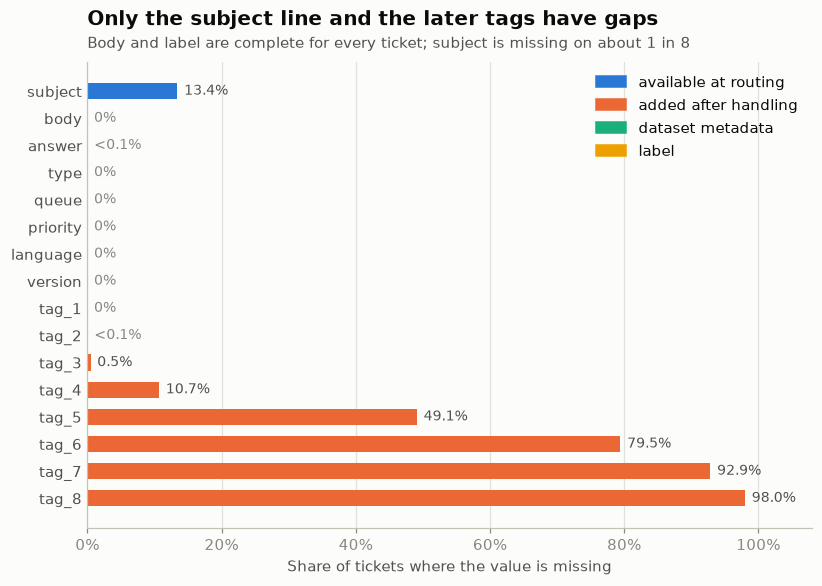

In [5]:
# Step 3 (chart 1) — missing values by column, coloured by role
missing_pct = df_raw.isna().mean().mul(100)[::-1]  # reversed so the first column sits at the top

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(missing_pct.index, missing_pct.values, height=0.6,
        color=[ROLE_COLORS[COLUMN_ROLES[c][0]] for c in missing_pct.index])
for y, v in enumerate(missing_pct.values):
    label = f"{v:.1f}%" if v >= 0.05 else ("<0.1%" if v > 0 else "0%")
    ax.text(v + 1, y, label, va="center", fontsize=9, color=INK_2 if v >= 0.05 else MUTED)

ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter())
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Share of tickets where the value is missing")
ax.set_title("Only the subject line and the later tags have gaps", pad=24)
ax.text(0, 1.03, "Body and label are complete for every ticket; subject is missing on about 1 in 8",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.legend(handles=[Patch(color=c, label=r) for r, c in ROLE_COLORS.items()], loc="upper right")
plt.show()

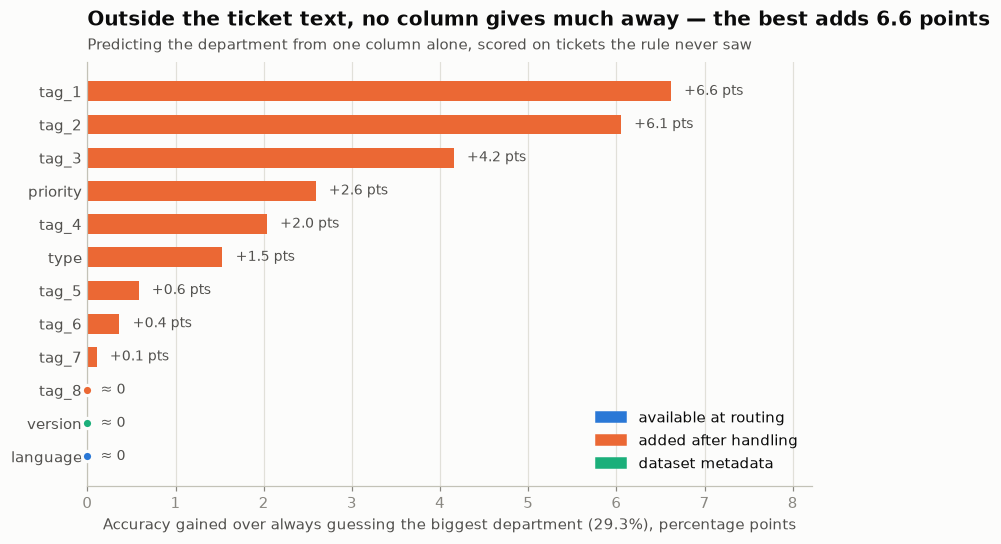

In [6]:
# Step 3 (chart 2) — how much would each non-text column give away about the department?
# Rule: predict the most common department for each value of the column. The rule is learned on one
# half of the tickets and scored on the other, so columns with hundreds of values can't just memorise.
from sklearn.model_selection import train_test_split

lookup_cols = [c for c in df_raw.columns if c not in TEXT_COLS + ["answer", LABEL]]
X_lookup = df_raw[lookup_cols].astype(str).fillna("<missing>")
X_learn, X_score, y_learn, y_score = train_test_split(
    X_lookup, df_raw[LABEL], test_size=0.5, random_state=SEED, stratify=df_raw[LABEL]
)
fallback = y_learn.mode()[0]
lookup_floor = (y_score == fallback).mean()

def lookup_accuracy(col):
    most_common_dept = y_learn.groupby(X_learn[col]).agg(lambda s: s.mode()[0])
    return (X_score[col].map(most_common_dept).fillna(fallback) == y_score).mean()

lift = pd.Series({c: lookup_accuracy(c) - lookup_floor for c in lookup_cols}).mul(100).sort_values()
lift_colors = [ROLE_COLORS[COLUMN_ROLES[c][0]] for c in lift.index]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(lift.index, lift.values, height=0.6, color=lift_colors)
for y, (v, color) in enumerate(zip(lift.values, lift_colors)):
    if v < 0.05:  # a zero-length bar is invisible, so mark it with a dot in its role colour
        ax.scatter(0, y, s=45, color=color, edgecolor=SURFACE, linewidth=2, zorder=3, clip_on=False)
    ax.text(max(v, 0) + 0.15, y, f"+{v:.1f} pts" if v >= 0.05 else "≈ 0", va="center", fontsize=9, color=INK_2)

ax.set_xlim(0, lift.max() + 1.6)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel(f"Accuracy gained over always guessing the biggest department ({lookup_floor:.1%}), percentage points")
ax.set_title(f"Outside the ticket text, no column gives much away — the best adds {lift.max():.1f} points", pad=24)
ax.text(0, 1.03, "Predicting the department from one column alone, scored on tickets the rule never saw",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
roles_shown = {COLUMN_ROLES[c][0] for c in lookup_cols}
ax.legend(handles=[Patch(color=c, label=r) for r, c in ROLE_COLORS.items() if r in roles_shown], loc="lower right")
plt.show()

In [7]:
# Step 3 (probe) — one column at a time is the weakest possible test. The fairer test: a real model
# given the excluded columns together, learned and scored on the same two halves as chart 2.
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

TAG_COLS = [f"tag_{i}" for i in range(1, 9)]

def after_handling_tokens(row, cols):
    # a tag counts the same whichever slot it sits in; type and priority keep their column name
    return [f"tag={v}" if c.startswith("tag_") else f"{c}={v}" for c, v in row[cols].dropna().items()]

probe = {}
for name, cols in [("all 8 tags together", TAG_COLS), ("tags + type + priority", TAG_COLS + ["type", "priority"])]:
    tokens = df_raw.apply(after_handling_tokens, axis=1, cols=cols)
    vec = CountVectorizer(analyzer=lambda toks: toks, binary=True)
    X_probe_learn = vec.fit_transform(tokens.loc[X_learn.index])
    pred = LogisticRegression(max_iter=2000).fit(X_probe_learn, y_learn).predict(vec.transform(tokens.loc[X_score.index]))
    acc = accuracy_score(y_score, pred)
    probe[name] = {"accuracy": acc, "gain over floor (pts)": (acc - lookup_floor) * 100,
                   "macro F1": f1_score(y_score, pred, average="macro")}

pd.DataFrame(probe).T.round(3)

,accuracy,gain over floor (pts),macro F1
all 8 tags together,0.375,8.206,0.233
tags + type + priority,0.422,12.977,0.283


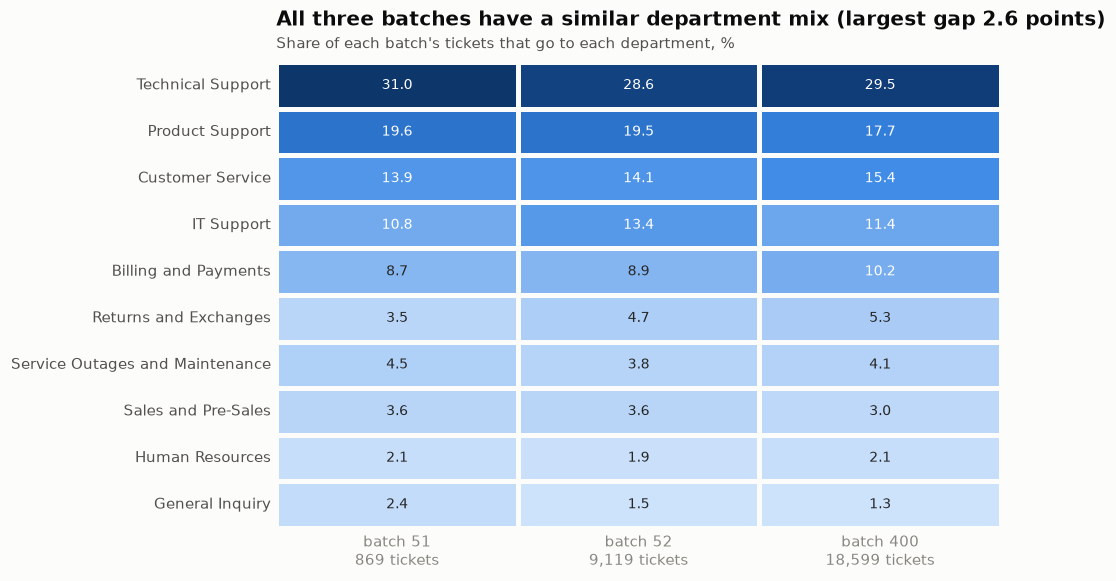

In [8]:
# Step 3 (chart 3) — does the department mix differ between the dataset's generation batches?
batch_sizes = df_raw["version"].value_counts()
batch_mix = pd.crosstab(df_raw[LABEL], df_raw["version"], normalize="columns").mul(100)
batch_mix = batch_mix.loc[df_raw[LABEL].value_counts().index]
batch_gap = (batch_mix.max(axis=1) - batch_mix.min(axis=1)).max()
batch_mix.columns = [f"batch {v}\n{batch_sizes[v]:,} tickets" for v in batch_mix.columns]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.heatmap(batch_mix, annot=True, fmt=".1f", cmap=BLUES, cbar=False, linewidths=2, linecolor=SURFACE,
            annot_kws={"fontsize": 9}, ax=ax)
ax.grid(False)
ax.tick_params(length=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"All three batches have a similar department mix (largest gap {batch_gap:.1f} points)", pad=24)
ax.text(0, 1.03, "Share of each batch's tickets that go to each department, %",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

### What Step 3 tells us

- **The model will only ever see `subject`, `body` and `language`.** Everything else is either the
  answer itself, or something a support agent adds after handling the ticket.
- **The excluded columns carry real but moderate signal.** One at a time (chart 2), the best column
  adds under 7 points of accuracy over the floor. Given to a real model *together* (the probe),
  tags + type + priority reach about 42% accuracy — roughly 13 points above the floor. They stay
  excluded regardless: the rule is about *what exists when a ticket arrives*, not about how much a
  column would help.
- **Worth noting, not yet concluding:** tags are written by someone who has read the ticket, yet
  even together they predict the department only moderately. Two explanations fit — the tags are
  generic (the same few appear across every department), or the department labels are loosely tied
  to the ticket's content. This notebook can't tell them apart yet; Step 4 takes a first look.
- **`subject` is missing on about 1 in 8 tickets** (chart 1). Those rows stay — `body` is never
  missing, so a missing subject is treated as empty text in Step 5 rather than a reason to drop the ticket.
- **The three generation batches (`version` 51, 52, 400) have a similar department mix** (chart 3,
  every department within about 3 points). The batches are unlikely to distort the splits in Step 12.

## Step 4 — Study the label (class balance)

**This is the most important early check.**

Count how many tickets each department has. If one department has 8,000 tickets and another
has 200, a model can score high accuracy by *always guessing the big one* — while being
completely useless on the small ones.

The department list at the top of this notebook comes from the dataset description. **The counts
below are the real list** — if they disagree, the data wins.

Three things to write down here:

1. **The imbalance ratio** — biggest class divided by smallest
2. **The floors** — the scores a model gets with no intelligence at all. Any real model has to
   beat these, or it's worth nothing:
   - *Always guess the biggest department* — sets the floor for **accuracy**. Its macro F1 is tiny:
     only the biggest department scores anything, the other nine score zero.
   - *Guess at random, in proportion to department sizes* — sets the floor for **macro F1**, the
     metric we'll actually judge models on (Step 16). Each department's precision and recall both
     equal its share, so its F1 equals its share — and the average over 10 departments is exactly 0.10.

   These floors describe the raw data. The floors that judge models are recomputed on the
   validation and test sets later (Steps 15 and 20), after cleaning and any language filter.
3. **Department share by language** — Step 9 may filter to English only. If departments are spread
   differently across languages, that filter quietly changes the class balance. Better to know now.

Also plot the counts. A bar chart of tickets per department makes the problem obvious at a glance.

### Read before modelling

Finally, read two tickets from each department. Some departments sound alike —
*Technical Support*, *IT Support* and *Product Support* could plausibly own the same ticket.
If a human can't tell them apart from the text, a model won't either. It gives a first, rough
sense of the realistic ceiling **before** any modelling.

In [9]:
# Step 4 — value_counts on the label, imbalance ratio, accuracy floor + macro-F1 floor
class_counts = df_raw[LABEL].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"{len(class_counts)} departments | largest: {class_counts.index[0]} ({class_counts.iloc[0]:,}) | "
      f"smallest: {class_counts.index[-1]} ({class_counts.iloc[-1]:,}) | imbalance ratio {imbalance_ratio:.1f}×\n")

# Floors = scores with no intelligence, using only how common each department is (share p).
# Computed exactly from the shares — no random draw, so the numbers never wobble between runs.
p = class_counts / class_counts.sum()
floors_all_tickets = pd.DataFrame(
    {"accuracy": [p.max(), (p ** 2).sum()],
     "macro F1": [2 * p.max() / (1 + p.max()) / len(p), 1 / len(p)]},
    index=["always guess the biggest department", "guess at random, in proportion to department size"],
)
floors_all_tickets.round(3)

10 departments | largest: Technical Support (8,362) | smallest: General Inquiry (405) | imbalance ratio 20.6×



,accuracy,macro F1
always guess the biggest department,0.293,0.045
"guess at random, in proportion to department size",0.171,0.100


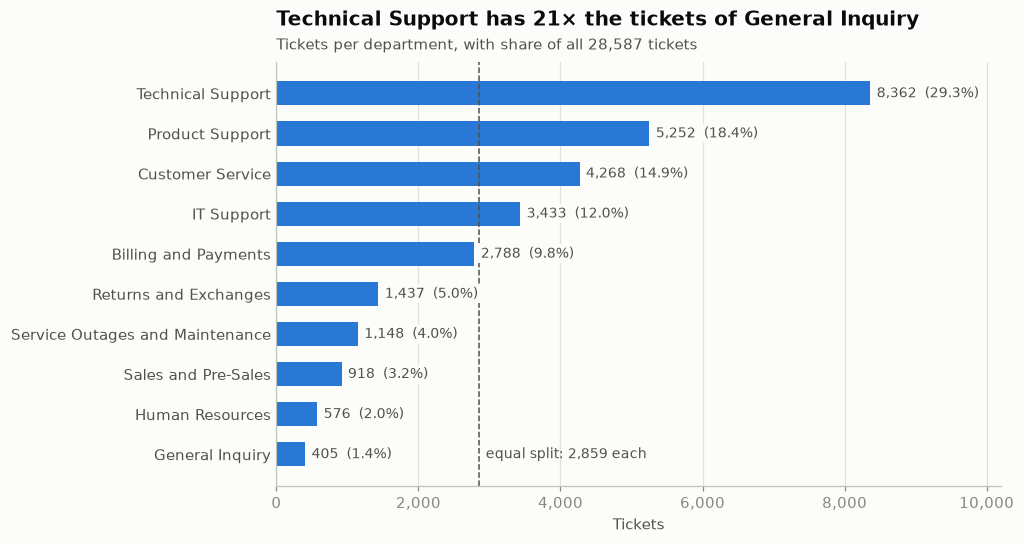

In [10]:
# Step 4 (plot) — horizontal bar chart of tickets per department
shares = class_counts / class_counts.sum()
equal_split = class_counts.sum() / len(class_counts)
label_box = dict(facecolor=SURFACE, edgecolor="none", pad=1.5)  # lets the reference line pass behind labels

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(class_counts.index[::-1], class_counts.values[::-1], height=0.6, color=CAT[0])
ax.axvline(equal_split, color=INK_2, linestyle="--", linewidth=1, zorder=1)
for y, (n, s) in enumerate(zip(class_counts.values[::-1], shares.values[::-1])):
    ax.text(n + 90, y, f"{n:,}  ({s:.1%})", va="center", fontsize=9, color=INK_2, bbox=label_box, zorder=2)
ax.text(equal_split + 90, 0, f"equal split: {equal_split:,.0f} each", va="center", fontsize=9, color=INK_2)

ax.set_xlim(0, class_counts.max() * 1.22)
ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Tickets")
ax.set_title(f"{class_counts.index[0]} has {imbalance_ratio:.0f}× the tickets of {class_counts.index[-1]}", pad=24)
ax.text(0, 1.03, f"Tickets per department, with share of all {class_counts.sum():,} tickets",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
plt.show()

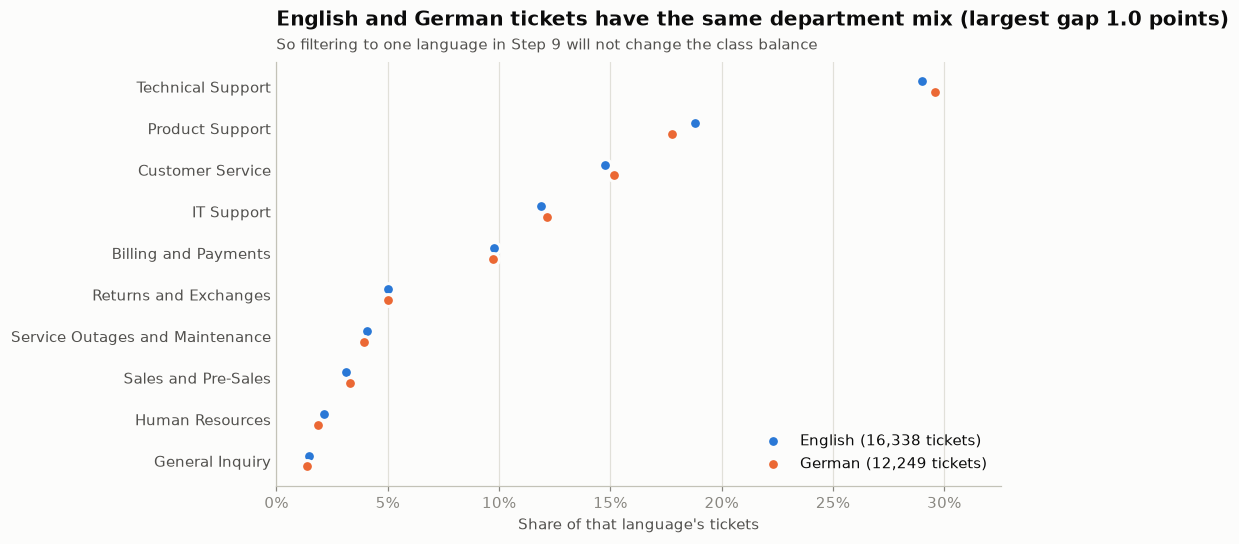

language,de,en
queue,,
Technical Support,29.6,29.0
Product Support,17.8,18.8
Customer Service,15.2,14.8
IT Support,12.2,11.9
Billing and Payments,9.7,9.8
Returns and Exchanges,5.0,5.0
Service Outages and Maintenance,4.0,4.1
Sales and Pre-Sales,3.3,3.1
Human Resources,1.9,2.1


In [11]:
# Step 4 (language) — department share by language
lang_counts = df_raw["language"].value_counts()
lang_mix = pd.crosstab(df_raw[LABEL], df_raw["language"], normalize="columns").mul(100).loc[class_counts.index[::-1]]
lang_gap = (lang_mix["en"] - lang_mix["de"]).abs().max()

fig, ax = plt.subplots(figsize=(8.5, 5))
rows = np.arange(len(lang_mix))
# English sits slightly above, German slightly below, so equal shares never hide one dot behind the other
for (code, name), color, offset in zip([("en", "English"), ("de", "German")], CAT, [0.13, -0.13]):
    ax.scatter(lang_mix[code], rows + offset, s=60, color=color, edgecolor=SURFACE, linewidth=2, zorder=3,
               label=f"{name} ({lang_counts[code]:,} tickets)")

ax.set_yticks(rows, lang_mix.index)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax.set_xlim(0, lang_mix.max().max() * 1.1)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Share of that language's tickets")
ax.set_title(f"English and German tickets have the same department mix (largest gap {lang_gap:.1f} points)", pad=24)
ax.text(0, 1.03, "So filtering to one language in Step 9 will not change the class balance",
        transform=ax.transAxes, fontsize=9.5, color=INK_2)
ax.legend(loc="lower right")
plt.show()

lang_mix.round(1).iloc[::-1]

In [12]:
# Step 4 (read) — print 2 sample tickets per department to judge how separable they are
# English only, so any reader can judge them. The seed means everyone sees the same tickets.
SAMPLES_PER_DEPT = 2
samples = (df_raw[df_raw["language"] == "en"]
           .groupby(LABEL, group_keys=False)
           .sample(SAMPLES_PER_DEPT, random_state=SEED))

for dept in class_counts.index:
    print(f"━━ {dept} " + "━" * max(3, 60 - len(dept)))
    for _, row in samples[samples[LABEL] == dept].iterrows():
        subject = row["subject"] if pd.notna(row["subject"]) else "(no subject)"
        body = " ".join(row["body"].split())
        print(f"  ▸ {subject}\n    {body[:200]}{'…' if len(body) > 200 else ''}\n")

━━ Technical Support ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▸ Concern About Recent Decline in Digital Campaign Metrics
    We have noticed a sudden drop in the performance metrics of our digital campaign. This may be due to recent software updates or configuration changes. Despite our efforts to troubleshoot by reviewing …

  ▸ Failure in High-Intensity Projector Automation Process
    Dear Support Team,\n\nI am submitting a report regarding an issue with the automation process of our high-brightness projector system. Recently, I have experienced repeated failures in the automation …

━━ Product Support ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▸ Concerns Regarding Security of Medical Information
    Facing difficulties in securing medical information within our hospital's IT system. The problem might stem from outdated security protocols. Efforts have been made to update firewall settings and per…

  ▸ Digital Strategy Challenge
    Facing difficulties in implementing the

### What Step 4 tells us

- **The classes are imbalanced, about 21 to 1.** Technical Support has 8,362 tickets; General Inquiry
  has 405. Four departments hold 74% of all tickets.
- **The floors on the raw data:** 29.3% accuracy (always guess Technical Support) and 0.10 macro F1
  (guess at random in proportion to department size). Always guessing the biggest department scores
  only 0.05 macro F1 — which is exactly why macro F1, not accuracy, is the metric that judges models later.
- **English and German have the same department mix** (within 1 point). Filtering to one language
  in Step 9 is safe for class balance.
- **Some labels do not appear to match their ticket.** In the sample above, *Human Resources* holds a
  product integration failure and a hospital security breach; *Returns and Exchanges* holds a
  medical-data breach and an investment-forecast bug. Billing, IT Support, Service Outages and
  General Inquiry read cleanly. In this sample, roughly 12 of the 20 tickets plausibly belong to
  their department.

**How much weight this can bear:** it's 20 tickets and one reader — an early sign, not a measurement.
If it holds up, it points to **label noise** (tickets assigned to a department their text doesn't
support), and no model can be right about a label the text contradicts. The realistic ceiling
would then sit well below 100%, and a modest score would not automatically mean a weak model.

**How it gets measured properly — Step 18.** Once a model is trained, the tickets where it
*confidently* disagrees with the label, across cross-validation folds, are the prime suspects for
label noise (the idea behind *confident learning*). Reading and counting those turns this early
sign into a number. Until then, results are judged by *how far above the floors* the model gets,
and *which departments* it can and can't learn.

---
# Phase 2 — Clean the data
*Steps 5 to 10*

## Step 5 — Build the text field

The model reads one block of text per ticket. We join `subject` and `body` together.

**Why both:** the subject often carries the strongest signal ("Invoice wrong" → Billing),
while the body carries the detail that resolves ambiguous cases.

Also record text length (characters and words) — we'll use it in the next step to find
tickets that are too short to be useful.

In [13]:
# Step 5 — combine subject + body into a single text column, add length columns

## Step 6 — Drop rows we can't use

Two kinds of rows have to go:

- **No label** — we can't train on them or score them
- **Almost no text** — a ticket with two words carries no real signal and just adds noise

Print how many rows each rule removes. Nothing should disappear silently; if a rule removes
40% of the data, you want to know that immediately rather than discover it later.

In [14]:
# Step 6 — drop rows with missing label or near-empty text, report counts

## Step 7 — Remove exact duplicates

**Why this matters more than it sounds:** if the same ticket text appears twice, and one copy
lands in training while the other lands in test, the model has effectively been handed the
answer key. The test score goes up and means nothing.

Remove exact repeats of the ticket text, keeping the first occurrence. Print a couple of
examples before dropping them — sometimes duplicates reveal a data collection bug worth knowing about.

In [15]:
# Step 7 — find and drop exact duplicate texts

## Step 8 — Remove near-duplicates

Exact matching misses tickets that differ only by a customer name, an order number, or a
stray space but are otherwise identical. Those leak just as badly as exact copies.

**Approach:** normalise each text (lowercase, strip digits and punctuation, collapse
whitespace) to create a comparison key, then drop repeats of that key. Fast, and catches
most real-world near-duplication.

Report the total rows removed across Steps 6–8 as a percentage of the original — if it's
large, that's a finding worth mentioning in the write-up.

In [16]:
# Step 8 — normalise text into a dedupe key, drop near-duplicate rows

## Step 9 — Decide what to do about language

This dataset mixes English, German, Spanish, French and Portuguese.

**Mixing languages by accident usually hurts,** because the model has to learn five
vocabularies at once from the same amount of data. Make it a deliberate choice:

| Option | Trade-off |
|---|---|
| **English only** | Fewer rows, cleaner signal, easier to interpret. Good first pass. |
| **All languages** | More data, harder problem, needs multilingual features to work well |

**Recommendation:** start English-only to get a trustworthy baseline, then re-run with all
languages later and compare. Set this as a switch at the top of the cell so it's easy to flip.

In [17]:
# Step 9 — inspect language distribution, apply LANGUAGE_MODE filter

## Step 10 — Light text cleaning

**Common mistake: over-cleaning.** Aggressive stemming and stopword removal often *hurt*
text models because they throw away real signal. Resist the urge.

Only remove what is clearly noise *and* clearly leaky:

- **Email addresses** → replace with a placeholder
- **URLs** → replace with a placeholder
- **Long digit strings** (order IDs, ticket numbers) → replace with a placeholder

These can act as accidental giveaways tied to one department, which inflates the score
without the model learning anything real.

**Keep** casing and normal punctuation. TF-IDF handles those fine.

In [18]:
# Step 10 — regex cleaning for emails, URLs, long numbers; show before/after

---
# Phase 3 — Prepare for modelling
*Steps 11 to 14*

## Step 11 — Handle very rare departments

If a department has only a handful of tickets, we can't train on it *or* score it honestly.
A stratified split needs at least a few examples of every class in every split.

**Two options:** drop those classes entirely, or merge them into an `Other` bucket.

**Prefer merging** — dropping silently pretends those tickets don't exist, which will
surprise someone in production when a real ticket arrives from that department.

Pick a minimum class size (30 is a reasonable starting point) and document the choice.

In [19]:
# Step 11 — merge classes below MIN_CLASS_SIZE into 'Other', show final distribution

## Step 12 — Split into train / validation / test

Three separate pieces, each with a distinct job:

| Split | Share | Job |
|---|---|---|
| **Train** | 70% | The model learns from this |
| **Validation** | 15% | Compare models, tune settings |
| **Test** | 15% | Locked away — opened exactly once, at Step 20 |

**Stratified** means each department keeps the same share across all three splits, so a small
department doesn't accidentally end up entirely inside one of them.

**Critical ordering:** the split happens *before* any balancing or vectorizing. Doing it the
other way round leaks information from test into training and inflates the final number.

Verify afterwards that the class shares match across the three splits — they should be
nearly identical.

In [20]:
# Step 12 — stratified train/val/test split, verify class shares match

## Step 13 — Turn text into numbers (TF-IDF)

Models need numbers, not words. TF-IDF scores each word by how often it appears in a ticket,
divided by how common it is across all tickets — so "invoice" counts for a lot and "the"
counts for almost nothing.

**Settings worth thinking about:**

- **`ngram_range=(1,2)`** — capture word pairs too, so "payment failed" is a feature, not
  just "payment" and "failed" separately
- **`min_df`** — ignore words appearing in very few tickets (usually typos)
- **`max_df`** — ignore words appearing in almost every ticket (no discriminating power)
- **`sublinear_tf`** — dampen the effect of a word repeated many times in one ticket

**The rule again:** `fit` on training data only. Validation and test get `transform` only.

In [21]:
# Step 13 — fit TfidfVectorizer on train, transform val and test

## Step 14 — Deal with class imbalance

From Step 4 we know some departments are much bigger than others. Two ways to handle it:

**Option 1 — Class weights.** Tell the model that getting a small class wrong costs more.
No data is duplicated or discarded. Usually the better choice for text.

**Option 2 — Resampling.** Duplicate small-class rows (oversample) or delete big-class rows
(undersample). Risks overfitting on duplicated rows, or throwing away real information.

**Recommendation: class weights.** If you do try resampling later, apply it to the
**training set only** — never to validation or test, or the scores stop reflecting reality.

Print the computed weights so it's visible that small classes are getting boosted.

In [22]:
# Step 14 — compute balanced class weights, display them against class counts

---
# Phase 4 — Baseline models
*Steps 15 to 16*

## Step 15 — Train 4 baseline models

**Always establish a floor before reaching for anything complicated.** If a simple model gets
you 90% of the way, an expensive model needs to justify itself.

| Model | Why it's in the lineup |
|---|---|
| **Dummy (most frequent)** | The "always guess the biggest department" score. The floor. Everything must beat it. |
| **Logistic Regression** | Standard strong baseline for text. Fast, interpretable, well-behaved probabilities. |
| **Linear SVM** | Often the best classical performer on sparse text data. |
| **Complement Naive Bayes** | Built specifically for imbalanced text. Extremely fast. |
| **Random Forest** | A non-linear comparison. Usually weaker on sparse text — worth confirming rather than assuming. |

**Score on validation, not test.** Test stays sealed until Step 20.

Record accuracy, macro F1, and weighted F1 for each.

In [23]:
# Step 15 — train the 4 baselines + dummy, collect validation scores

## Step 16 — Compare the baselines properly

**Accuracy alone can lie here.** With imbalanced classes, a model can post good accuracy
while completely failing the small departments.

**Macro F1 is the primary metric.** It treats every department equally regardless of size.

**The diagnostic:** if accuracy is high but macro F1 is much lower, the model is quietly
ignoring the small classes. That gap is the imbalance problem showing up in the numbers.

Plot both metrics side by side per model, with the dummy floor drawn as a reference line.
Pick the winner by macro F1 and carry it into Step 17.

In [24]:
# Step 16 — grouped bar chart of accuracy vs macro F1, mark the dummy floor, select best

---
# Phase 5 — Improve and diagnose
*Steps 17 to 19*

## Step 17 — Tune the best model

Search over the winner's settings to squeeze out more performance.

**Where to tune:** use **cross-validation on the training set** — not the validation set, and
definitely not the test set. Tuning repeatedly against validation slowly overfits to it, and
the validation score stops being a fair estimate.

**What to search:** the vectorizer settings and the model's regularisation strength together,
since they interact.

**`RandomizedSearchCV` over `GridSearchCV`** — it samples a fixed number of combinations
instead of trying every one. Far cheaper, and usually finds something just as good.

Compare the tuned score against the baseline score. If tuning gained you 0.3%, say so plainly
rather than presenting it as a breakthrough.

In [25]:
# Step 17 — RandomizedSearchCV over pipeline, report best params and gain vs baseline

## Step 18 — Error analysis

A single score hides *where* the model fails. Three things to look at, in order:

**1. Per-class scores.** Which departments is it bad at? Small classes usually. Name the
worst three explicitly.

**2. Confusion matrix.** Which pairs does it mix up? Context matters here — Billing confused
with Payments is understandable and might be acceptable in production. Billing confused with
HR would signal something genuinely broken.

**3. Read real misclassified tickets.** Often the most useful five minutes in the whole
notebook. A large share of "errors" turn out to be genuinely ambiguous tickets that two
departments could legitimately own — which means the ceiling is lower than 100% and that's
fine.

Normalise the confusion matrix by row so each row sums to 1.0, otherwise the big classes
visually dominate and you can't see anything.

In [26]:
# Step 18a — per-class classification report, identify weakest classes

In [27]:
# Step 18b — normalised confusion matrix heatmap, list most-confused pairs

In [28]:
# Step 18c — print a handful of actual misclassified tickets to read

## Step 19 — Check and fix the confidence scores (calibration)

Getting the answer right is one thing. Knowing *how sure* it is, is another.

**A well-calibrated model that says "85% confident" is right about 85% of the time when it
says that.** That matters in production — it's what lets you auto-route the confident tickets
and send the uncertain ones to a human.

**Measure first:** Expected Calibration Error (ECE) — how far stated confidence drifts from
actual accuracy. Lower is better. Also track log-loss.

**Then fix if needed:** isotonic regression or Platt scaling, fitted on validation.

**Then check the fix actually helped.** It doesn't always. Calibration corrects a distortion —
if the model was already honest, applying it can make things worse. Only keep the calibrated
version if ECE genuinely improved, and say which way it went.

Plot a reliability curve before and after, with dot size showing how many tickets fall in each
confidence bin — otherwise a wild-looking line from a 3-ticket bin misleads you.

In [29]:
# Step 19a — compute ECE and log-loss before and after calibration, decide which to keep

In [30]:
# Step 19b — reliability curve plot, before vs after

---
# Phase 6 — Finalize
*Step 20*

## Step 20 — Final evaluation, save, and document

**The test set gets opened once, here.** Whatever number comes out is the number we report.
No going back to tune after seeing it — that's the entire reason it was held back.

**Report:**
- Accuracy, macro F1, weighted F1, ECE
- How far it beat the floors — recomputed **on the test set itself**, not carried over from Step 4

**Plot:**
- Final confusion matrix on test
- The journey: floor → best baseline → tuned → final. Shows how much was actually gained.

**Save:**
- The fitted model to `artifacts/`
- A **model card** as JSON

**The model card is not optional.** It should state plainly:
- What the model does and what data it was trained on
- Which languages it covers (and therefore which it doesn't)
- Its weakest departments, by name and score
- Which department pairs it confuses, and whether that's acceptable
- That it was trained on one dataset from one source and needs revalidation on real traffic

Writing down what a model *can't* do is what separates a professional result from a demo.

In [31]:
# Step 20a — predict on test set once, report all final metrics vs the floor

In [32]:
# Step 20b — final confusion matrix + progress-from-floor chart

In [33]:
# Step 20c — save model with joblib, write model_card.json with known limitations

---
## Done — and what comes next

**What we end up with:** a trained, tuned, calibration-checked department classifier,
evaluated once on data it never saw, with its weaknesses written down honestly.

**Sensible next experiments:**

1. **Re-run with `LANGUAGE_MODE = "all"`** and compare against the English-only numbers.
   Does more data beat cleaner data here?
2. **Try a transformer** (e.g. a multilingual sentence model) against this baseline. Only
   worth adopting if it *clearly* beats these numbers — otherwise the classical model wins
   on cost and speed.
3. **Set a confidence threshold.** Auto-route tickets above it, send the rest to a human.
   Step 19's calibration is what makes that threshold trustworthy.
4. **Compare against Jev** on this exact test set, if API access comes through. That would
   turn the article's vendor-published numbers into first-hand ones.